### Import the libraries

In [2]:
import numpy as np
import tensorflow as tf
from keras.layers import *
from keras.models import Model
from keras.datasets import imdb
from tensorflow.python.eager.execute import make_shape
from torch.onnx.ops import attention

### load the dataset

In [3]:
vocab_size = 20000
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=vocab_size)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [4]:
x_train.shape

(25000,)

In [5]:
x_test.shape

(25000,)

### Define Hyperparameters

In [6]:
maxlen = 200
embed_dim = 32
num_head = 2
ff_dim = 32

### Data Preprocessing

In [7]:
from keras.preprocessing.sequence import pad_sequences

In [8]:
x_train = pad_sequences(x_train, maxlen=maxlen)
x_test = pad_sequences(x_test, maxlen=maxlen)

In [9]:
x_train.shape

(25000, 200)

In [10]:
x_train[0]

array([    5,    25,   100,    43,   838,   112,    50,   670,     2,
           9,    35,   480,   284,     5,   150,     4,   172,   112,
         167,     2,   336,   385,    39,     4,   172,  4536,  1111,
          17,   546,    38,    13,   447,     4,   192,    50,    16,
           6,   147,  2025,    19,    14,    22,     4,  1920,  4613,
         469,     4,    22,    71,    87,    12,    16,    43,   530,
          38,    76,    15,    13,  1247,     4,    22,    17,   515,
          17,    12,    16,   626,    18, 19193,     5,    62,   386,
          12,     8,   316,     8,   106,     5,     4,  2223,  5244,
          16,   480,    66,  3785,    33,     4,   130,    12,    16,
          38,   619,     5,    25,   124,    51,    36,   135,    48,
          25,  1415,    33,     6,    22,    12,   215,    28,    77,
          52,     5,    14,   407,    16,    82, 10311,     8,     4,
         107,   117,  5952,    15,   256,     4,     2,     7,  3766,
           5,   723,

### Build the Model

In [14]:
# Input Layer
inputs = Input(shape=(maxlen,))

# Token Embedding Layer
token_emb_layer = Embedding(input_dim=vocab_size, output_dim=embed_dim)
x = token_emb_layer(inputs)

# Positional Embedding Layer
positions = tf.range(0, maxlen)
pos_emb_layer = Embedding(input_dim=maxlen, output_dim=embed_dim)
positions_emb = pos_emb_layer(positions)

# Add the token + position embedding
x = x + positions_emb

# Add transformer block
# 1. Multi-head self Attention
attention_output = MultiHeadAttention(
    num_heads = num_head,
    key_dim = embed_dim) (x, x)

attention_output = Dropout(0.1)(attention_output)

# Residual connections (add+norm)
x1 = LayerNormalization()(x + attention_output)

# Feed forward neural network
ffn = Dense(ff_dim, activation="relu")(x1)
ffn = Dense(embed_dim)(ffn)
ffn = Dropout(0.1)(ffn)

# Residual connections (add+norm)
x2 = LayerNormalization()(x1 + ffn)

# Classification Head
x3 = GlobalAveragePooling1D()(x2)
x3 = Dropout(0.1)(x3)
x3 = Dense(20, activation="relu")(x3)
x3 = Dropout(0.1)(x3)

# Output Layer
outputs = Dense(1, activation="sigmoid")(x3)

In [15]:
# Create object of model
model = Model(inputs=inputs, outputs=outputs)

In [17]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 200)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 200, 32)   │    640,000 │ input_layer_1[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 200, 32)   │          0 │ embedding_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 200, 32)   │      8,416 │ add[0][0],        │
│ (MultiHeadAttentio… │                   │            │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 200, 32)   │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 200, 32)   │          0 │ add[0][0],        │
│                     │                   │            │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 200, 32)   │         64 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 200, 32)   │      1,056 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 200, 32)   │      1,056 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 200, 32)   │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 200, 32)   │          0 │ layer_normalizat… │
│                     │                   │            │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 200, 32)   │         64 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 32)        │          0 │ layer_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 32)        │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 20)        │        660 │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 20)        │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 1)         │         21 │ dropout_4[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 651,337 (2.48 MB)

 Trainable params: 651,337 (2.48 MB)

 Non-trainable params: 0 (0.00 B)

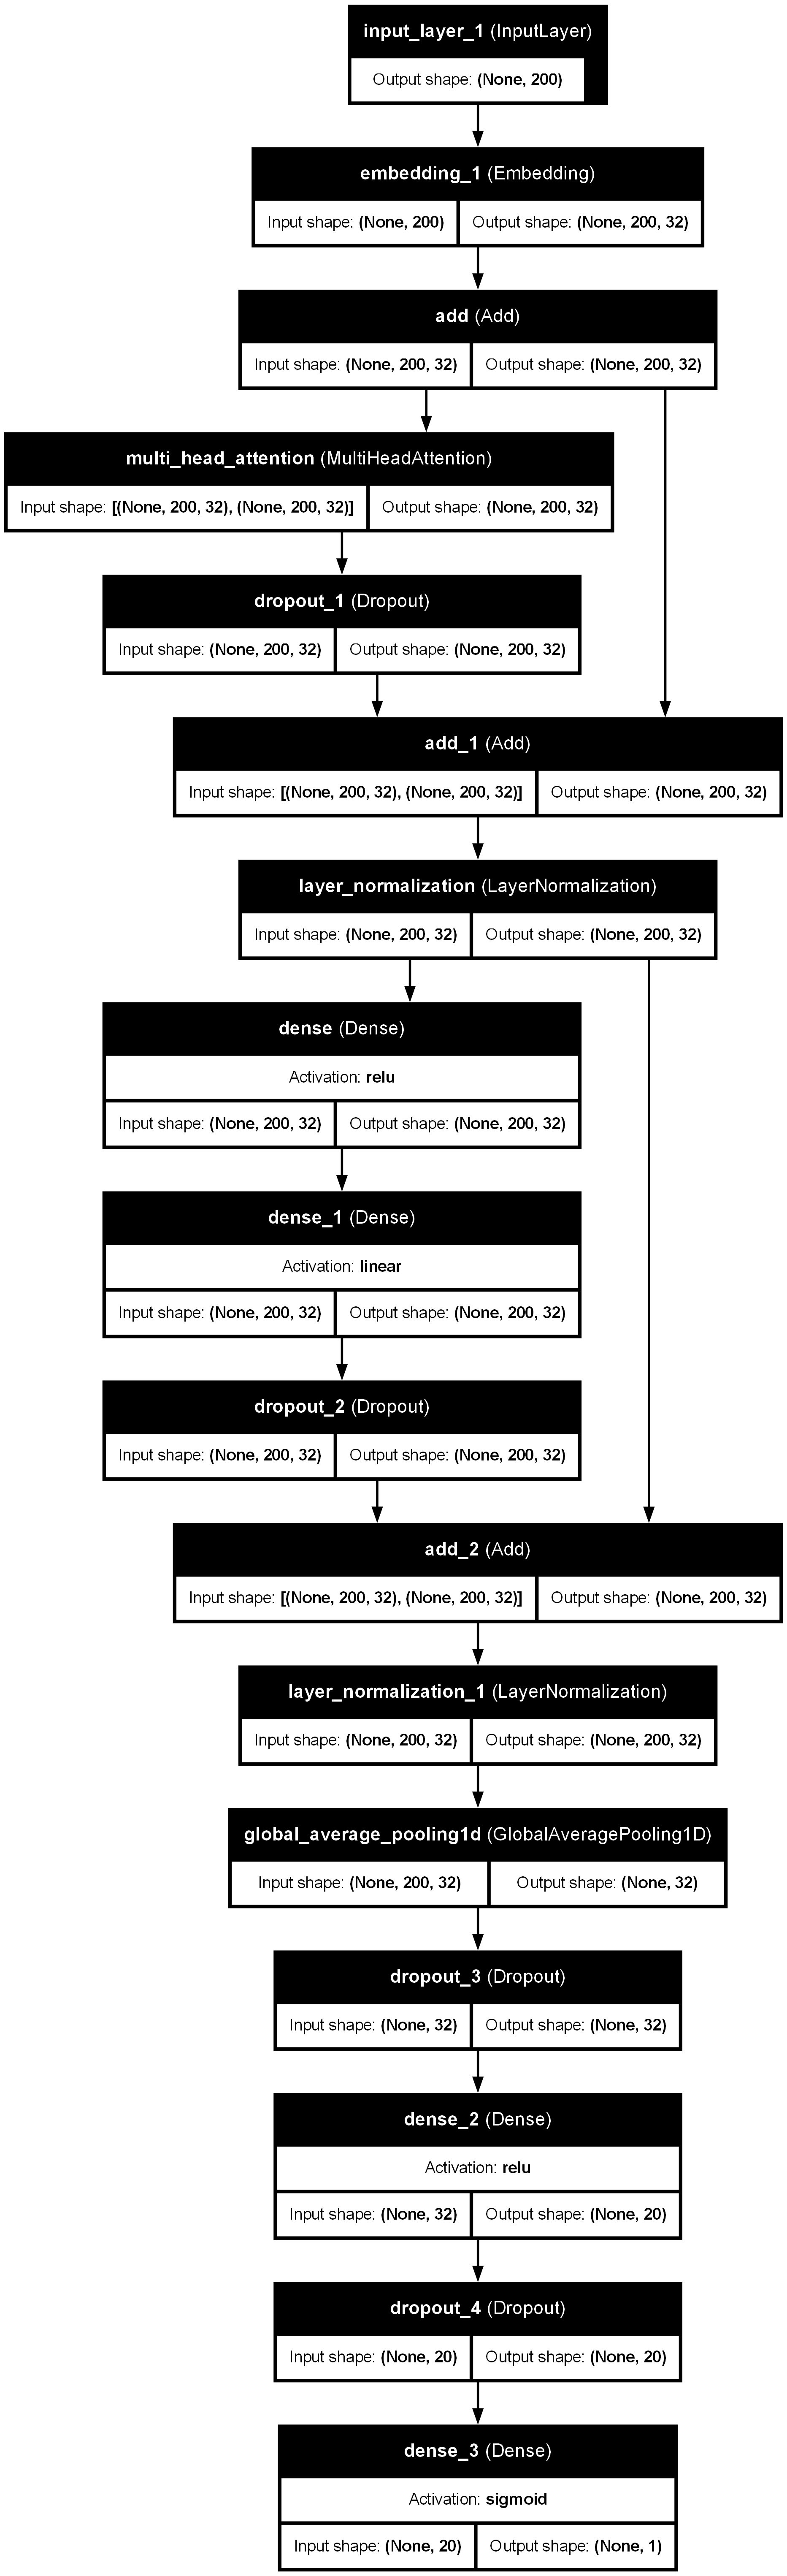

In [18]:
from keras.utils import plot_model
plot_model(model, show_layer_names= True, show_layer_activations=True, show_shapes=True)

In [19]:
# Compile the model

model.compile(loss="binary_crossentropy", optimizer="adam", metrics=["accuracy"])

In [21]:
# Train the model
history = model.fit(x_train, y_train, batch_size=32, epochs=5,
                    validation_data=(x_test, y_test), verbose=2)

Epoch 1/5
782/782 - 31s - 39ms/step - accuracy: 0.9895 - loss: 0.0363 - val_accuracy: 0.8406 - val_loss: 0.6454
Epoch 2/5
782/782 - 31s - 40ms/step - accuracy: 0.9912 - loss: 0.0293 - val_accuracy: 0.8340 - val_loss: 0.7973
Epoch 3/5
782/782 - 31s - 39ms/step - accuracy: 0.9934 - loss: 0.0202 - val_accuracy: 0.8334 - val_loss: 1.0875
Epoch 4/5
782/782 - 32s - 41ms/step - accuracy: 0.9948 - loss: 0.0157 - val_accuracy: 0.8340 - val_loss: 0.9980
Epoch 5/5
782/782 - 32s - 41ms/step - accuracy: 0.9957 - loss: 0.0128 - val_accuracy: 0.8274 - val_loss: 1.0953


In [34]:
new = x_test[800]

In [35]:
import numpy as np
new = np.reshape(new, (1, maxlen))

In [36]:
new.shape

(1, 200)

In [37]:
model.predict(new)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step


array([[0.9999825]], dtype=float32)